In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv("/content/stock_details_5_years.csv")
print(df.head())

                        Date        Open        High         Low       Close  \
0  2018-11-29 00:00:00-05:00   43.829761   43.863354   42.639594   43.083508   
1  2018-11-29 00:00:00-05:00  104.769074  105.519257  103.534595  104.636131   
2  2018-11-29 00:00:00-05:00   54.176498   55.007500   54.099998   54.729000   
3  2018-11-29 00:00:00-05:00   83.749496   84.499496   82.616501   83.678497   
4  2018-11-29 00:00:00-05:00   39.692784   40.064904   38.735195   39.037853   

      Volume  Dividends  Stock Splits Company  
0  167080000       0.00           0.0    AAPL  
1   28123200       0.00           0.0    MSFT  
2   31004000       0.00           0.0   GOOGL  
3  132264000       0.00           0.0    AMZN  
4   54917200       0.04           0.0    NVDA  


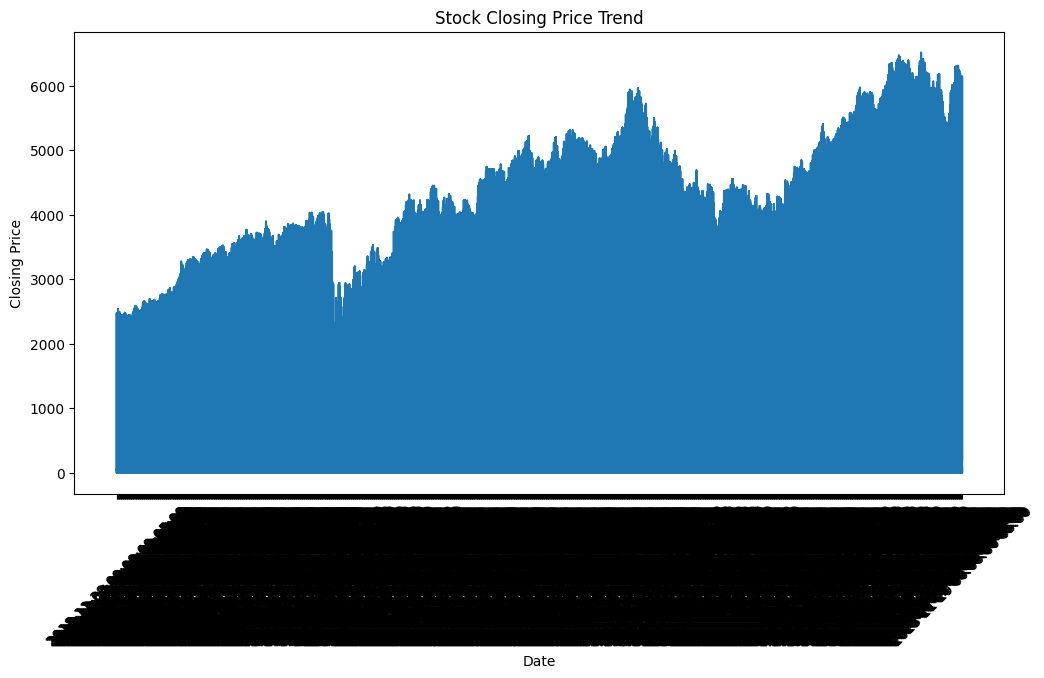

In [4]:
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'])
plt.title("Stock Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.show()

In [5]:
df = df.reset_index()

df['Day'] = np.arange(len(df))

X = df[['Day']]
y = df['Close']

In [6]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [7]:
future_days = np.arange(len(df), len(df)+30).reshape(-1,1)

predictions = model.predict(future_days)

print(predictions)

[182.98365843 182.98380068 182.98394294 182.9840852  182.98422746
 182.98436972 182.98451198 182.98465424 182.9847965  182.98493876
 182.98508102 182.98522327 182.98536553 182.98550779 182.98565005
 182.98579231 182.98593457 182.98607683 182.98621909 182.98636135
 182.98650361 182.98664586 182.98678812 182.98693038 182.98707264
 182.9872149  182.98735716 182.98749942 182.98764168 182.98778394]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


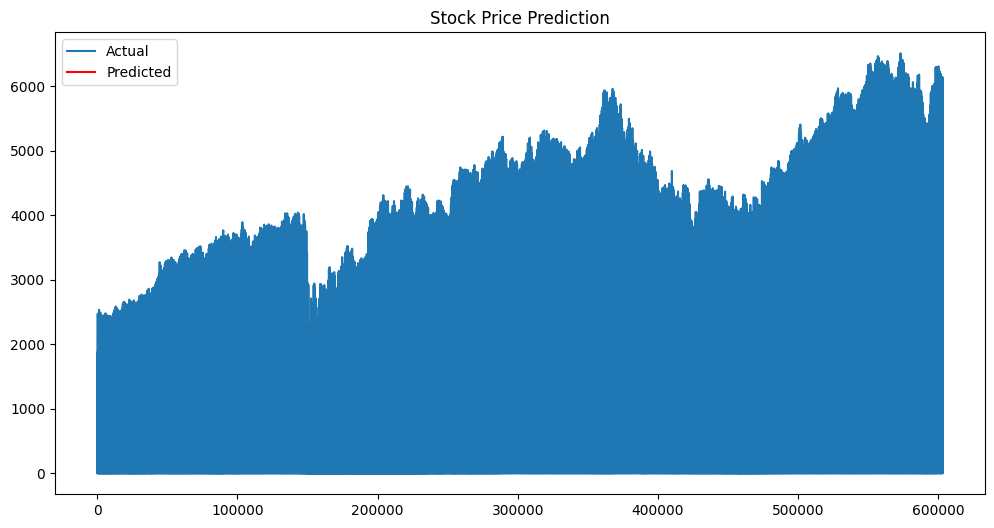

In [8]:
plt.figure(figsize=(12,6))

plt.plot(df['Day'], y, label='Actual')

plt.plot(
    future_days,
    predictions,
    color='red',
    label='Predicted'
)

plt.legend()
plt.title("Stock Price Prediction")
plt.show()

/tmp/ipykernel_5314/1639793938.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Next 30 Day Predictions:
Day 1: $217.87
Day 2: $217.98
Day 3: $218.08
Day 4: $218.19
Day 5: $218.29
Day 6: $218.40
Day 7: $218.50
Day 8: $218.61
Day 9: $218.72
Day 10: $218.82
Day 11: $218.93
Day 12: $219.03
Day 13: $219.14
Day 14: $219.24
Day 15: $219.35
Day 16: $219.46
Day 17: $219.56
Day 18: $219.67
Day 19: $219.77
Day 20: $219.88
Day 21: $219.98
Day 22: $220.09
Day 23: $220.19
Day 24: $220.30
Day 25: $220.41
Day 26: $220.51
Day 27: $220.62
Day 28: $220.72
Day 29: $220.83
Day 30: $220.93


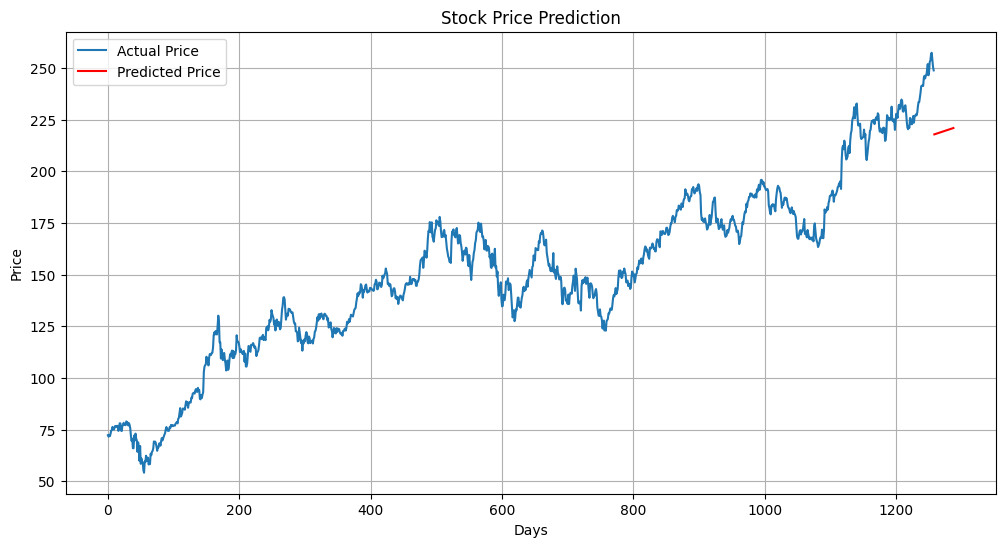

In [11]:
import yfinance as yf

# Download stock data
df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")

# Reset index
df = df.reset_index()

# Create day number
df['Day'] = np.arange(len(df))

# Features and Target
X = df[['Day']]
y = df['Close']

# Train Model
model = LinearRegression()
model.fit(X, y)

# Predict next 30 days
future_days = np.arange(len(df), len(df)+30).reshape(-1,1)
future_prices = model.predict(future_days)

# Print Predictions
print("Next 30 Day Predictions:")
for i, price in enumerate(future_prices, 1):
    print(f"Day {i}: ${price[0]:.2f}")

# Plot
plt.figure(figsize=(12,6))
plt.plot(df['Day'], y, label='Actual Price')
plt.plot(future_days, future_prices, color='red', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.title('Stock Price Prediction')
plt.legend()
plt.grid(True)
plt.show()